# Module 1 — CPU Preprocessing

This notebook prepares Alibaba Cluster Trace CPU data for long-term forecasting (Hybrid Prophet + GRU and Global GRU).

## Methodology notes

**15-minute resampling** — Module 1 forecasts on a fixed 15-minute grid (96 steps = 24 hours). Resampling to `15min` aligns irregular raw telemetry with the model input/output window used in both architectures.

**Linear interpolation** — Empty resampled bins are filled with linear interpolation per container. This preserves temporal continuity on a regular grid without inventing values beyond adjacent observations, which supports stable sequence generation for GRU models.

**Chronological splitting** — Each container is split 80/20 by time (not randomly). Future validation data must never influence training-time preprocessing, which is required for valid temporal holdout evaluation.

**MinMaxScaler on training data only** — Normalization parameters are fit on the train partition only, then applied to validation. Fitting on the full series would leak future validation statistics into training and inflate reported accuracy.

**Train-degenerate container removal** — Containers whose training partition has zero variance (or a single CPU value) produce invalid MinMax scalers and meaningless scaled features. These are excluded after the temporal split so validation-only activity cannot keep an otherwise unusable series in the modeling set.

In [68]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# --- Preprocessing configuration ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("../data")
RAW_CSV_PATH = DATA_DIR / "container_usage.csv"
TRAIN_PARQUET_PATH = DATA_DIR / "train_df.parquet"
VAL_PARQUET_PATH = DATA_DIR / "val_df.parquet"
DF_RESAMPLED_PARQUET_PATH = DATA_DIR / "df_resampled.parquet"
SCALERS_PKL_PATH = DATA_DIR / "scalers.pkl"
METADATA_PATH = DATA_DIR / "container_metadata.parquet"
SUMMARY_JSON_PATH = DATA_DIR / "preprocessing_summary.json"

MIN_ROWS_HIGH_QUALITY = 1100
MIN_ROWS_USABLE = 200
MIN_ROWS_RESAMPLED = 200
TRAIN_SPLIT_RATIO = 0.8
RESAMPLE_FREQ = "15min"
CV_LOW_QUANTILE = 0.33
CV_HIGH_QUANTILE = 0.66
NORMALIZATION_METHOD = "MinMaxScaler(feature_range=(0, 1))"

In [69]:
df = pd.read_csv(RAW_CSV_PATH)

In [70]:
df["time_stamp"] = pd.to_datetime(df["time_stamp"], unit="s")
df.head()

,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
0,NaN,m_108,1970-01-09 01:25:30,20.0,56,NaN,NaN,NaN,0.0,0.0,2.0
1,NaN,m_108,1970-01-09 02:02:50,14.0,64,1.56,0.00,0.0,0.0,0.0,4.0
2,NaN,m_108,1970-01-09 02:03:40,12.0,64,1.46,0.03,0.0,0.0,0.0,4.0
3,NaN,m_108,1970-01-09 02:04:30,10.0,64,1.74,0.00,0.0,0.0,0.0,5.0
4,NaN,m_108,1970-01-09 02:22:20,7.0,65,1.57,0.02,0.0,0.0,0.0,6.0


In [71]:
print(df["container_id"].isnull().sum())
print(df["container_id"].notnull().sum())
print(df["container_id"].nunique())

3503
31666497
33519


In [72]:
df_clean = df.dropna(subset=["container_id"])

In [73]:
container_counts = df["container_id"].value_counts().reset_index()
container_counts.columns = ["container_id", "row_count"]
container_counts

,container_id,row_count
0,c_30063,1167
1,c_21977,1156
2,c_26015,1156
3,c_26395,1155
4,c_35563,1152
...,...,...
33514,c_33642,45
33515,c_29356,42
33516,c_25422,37
33517,c_21430,5


In [74]:
stats = df.groupby("container_id")["cpu_util_percent"].agg([
    "mean",
    "std",
    "min",
    "max"
]).reset_index()

stats["cv"] = stats["std"] / stats["mean"]

In [75]:
low_threshold = stats["cv"].quantile(CV_LOW_QUANTILE)
high_threshold = stats["cv"].quantile(CV_HIGH_QUANTILE)

def label(cv):
    if cv <= low_threshold:
        return "stable"
    elif cv >= high_threshold:
        return "spiky"
    else:
        return "medium"

stats["type"] = stats["cv"].apply(label)

In [76]:
row_counts = df.groupby("container_id").size().reset_index(name="total_rows")

stats = stats.merge(row_counts, on="container_id", how="left")

In [77]:
stats_sorted = stats.sort_values("total_rows", ascending=False)
stats_sorted[["container_id", "total_rows", "mean", "std", "cv", "type"]]

,container_id,total_rows,mean,std,cv,type
21105,c_30063,1167,10.995716,2.248495,0.204488,stable
16841,c_26015,1156,1.189446,0.884455,0.743586,spiky
12598,c_21977,1156,9.227509,7.451962,0.807581,spiky
17241,c_26395,1155,8.550649,2.564554,0.299925,stable
26852,c_35563,1152,2.921875,1.165299,0.398819,medium
...,...,...,...,...,...,...
24857,c_33642,45,48.400000,9.355115,0.193288,stable
20364,c_29356,42,12.261905,4.585553,0.373967,medium
16219,c_25422,37,1.972973,1.040472,0.527363,spiky
12019,c_21430,5,14.200000,1.923538,0.135460,stable


In [78]:
high_quality_count = stats[stats["total_rows"] >= MIN_ROWS_HIGH_QUALITY].shape[0]
usable_count = stats[stats["total_rows"] >= MIN_ROWS_USABLE].shape[0]
unusable_count = stats[stats["total_rows"] < MIN_ROWS_USABLE].shape[0]
print(high_quality_count)
print(usable_count)
print(unusable_count)

511
32970
549


In [79]:
df_hq = stats[stats["total_rows"] >= MIN_ROWS_HIGH_QUALITY]
summary = df_hq["type"].value_counts().reset_index()
summary.columns = ["pattern_type", "count"]
summary["percentage"] = (summary["count"] / summary["count"].sum()) * 100
summary

,pattern_type,count,percentage
0,medium,175,34.246575
1,spiky,169,33.072407
2,stable,167,32.681018


In [80]:
bad_containers = df_hq[
    (df_hq["mean"] == 0) |
    (df_hq["std"] == 0) |
    (df_hq["cv"].isna())
]

In [81]:
clean_selected = df_hq.drop(bad_containers.index)
clean_selected.head()

,container_id,mean,std,min,max,cv,type,total_rows
35,c_10032,2.679211,1.270979,1.0,21.0,0.474386,medium,1116
37,c_10034,12.089350,6.673719,2.0,43.0,0.552033,spiky,1108
95,c_10089,9.589029,2.968964,4.0,20.0,0.309621,stable,1112
141,c_10132,2.958484,1.130225,2.0,10.0,0.382028,medium,1108
169,c_1016,2.274423,1.255814,1.0,28.0,0.552146,spiky,1126


In [82]:
container_ids = clean_selected["container_id"].tolist()

In [83]:
df_final = df_clean[df_clean["container_id"].isin(container_ids)]
df_final.head()

,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
36094,c_10032,m_34,1970-01-02 00:03:20,1.0,19,NaN,NaN,NaN,0.01,0.01,2.0
36095,c_10032,m_34,1970-01-02 00:22:10,2.0,19,NaN,NaN,NaN,0.01,0.01,9.0
36096,c_10032,m_34,1970-01-02 00:52:30,1.0,19,NaN,NaN,NaN,0.01,0.01,NaN
36097,c_10032,m_34,1970-01-02 00:53:30,1.0,19,NaN,NaN,NaN,0.01,0.01,3.0
36098,c_10032,m_34,1970-01-02 00:55:30,1.0,19,NaN,NaN,NaN,0.01,0.01,4.0


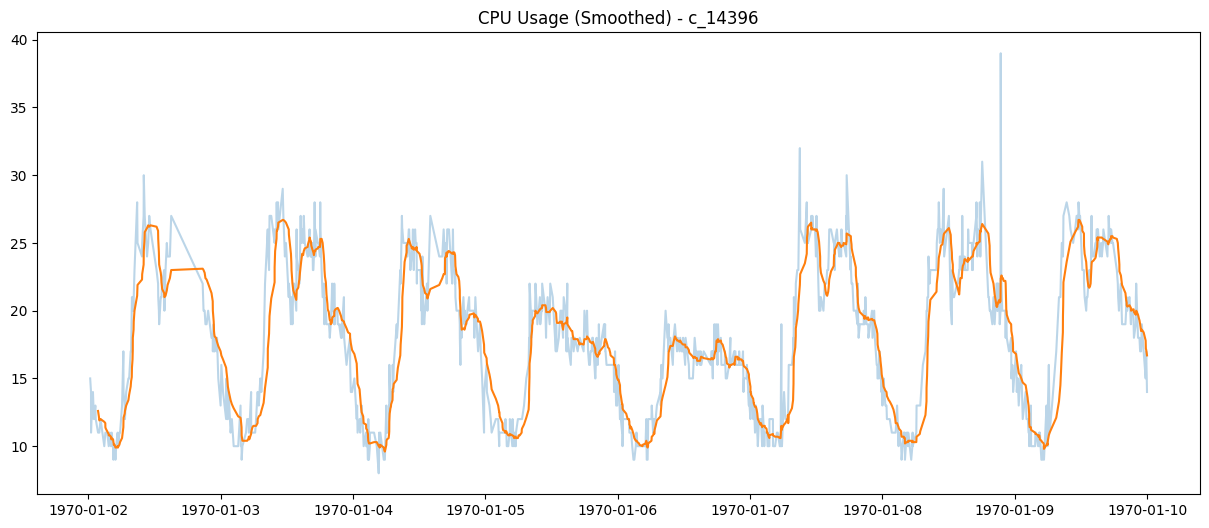

In [84]:
container_id = "c_14396"

df[df["container_id"] == container_id]

df_c = df[df["container_id"] == container_id].copy()
df_c = df_c.sort_values("time_stamp")

df_c["cpu_smooth"] = df_c["cpu_util_percent"].rolling(window=10).mean()

df_c

plt.figure(figsize=(15, 6))
plt.plot(df_c["time_stamp"], df_c["cpu_util_percent"], alpha=0.3)
plt.plot(df_c["time_stamp"], df_c["cpu_smooth"])
plt.title(f"CPU Usage (Smoothed) - {container_id}")
plt.show()

In [85]:
df_final = df_final.sort_values(["container_id", "time_stamp"])

Resampling

In [86]:
cpu_resampled = (
    df_final
    .set_index("time_stamp")
    .groupby("container_id")["cpu_util_percent"]
    .resample(RESAMPLE_FREQ)
    .mean()
    .reset_index()
)

In [87]:
cpu_resampled[cpu_resampled["container_id"] == container_id].head()

,container_id,time_stamp,cpu_util_percent
50596,c_14396,1970-01-02 00:15:00,13.333333
50597,c_14396,1970-01-02 00:30:00,12.000000
50598,c_14396,1970-01-02 00:45:00,13.000000
50599,c_14396,1970-01-02 01:00:00,NaN
50600,c_14396,1970-01-02 01:15:00,12.500000


Interpolation

In [88]:
cpu_resampled["cpu_usage"] = (
    cpu_resampled
    .groupby("container_id")["cpu_util_percent"]
    .transform(lambda x: x.interpolate())
)

In [89]:
cpu_resampled[cpu_resampled["container_id"] == container_id].head()

,container_id,time_stamp,cpu_util_percent,cpu_usage
50596,c_14396,1970-01-02 00:15:00,13.333333,13.333333
50597,c_14396,1970-01-02 00:30:00,12.000000,12.000000
50598,c_14396,1970-01-02 00:45:00,13.000000,13.000000
50599,c_14396,1970-01-02 01:00:00,NaN,12.750000
50600,c_14396,1970-01-02 01:15:00,12.500000,12.500000


In [90]:
other_cols = df_final.drop(
    columns=["cpu_util_percent"]
)

In [91]:
df_resampled = pd.merge(
    cpu_resampled,
    other_cols,
    on=["container_id", "time_stamp"],
    how="left"
)

In [92]:
df_resampled.head()

,container_id,time_stamp,cpu_util_percent,cpu_usage,machine_id,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
0,c_10032,1970-01-02 00:00:00,1.00,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c_10032,1970-01-02 00:15:00,2.00,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c_10032,1970-01-02 00:30:00,NaN,1.625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c_10032,1970-01-02 00:45:00,1.25,1.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,c_10032,1970-01-02 01:00:00,1.00,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Min-Max Normalisation

In [93]:
from sklearn.preprocessing import MinMaxScaler

train_list = []
val_list = []
scalers = {}
removed_degenerate = []

for cid, group in df_resampled.groupby("container_id"):
    group = group.sort_values("time_stamp").copy()

    if len(group) < MIN_ROWS_RESAMPLED:
        continue

    # Use the interpolated column
    group['cpu'] = group['cpu_usage']

    # ------------------- Temporal Split -------------------
    split_idx = int(len(group) * TRAIN_SPLIT_RATIO)
    train_part = group.iloc[:split_idx].copy()
    val_part = group.iloc[split_idx:].copy()

    # ------------------- Train-degenerate filter -------------------
    if train_part["cpu"].nunique() <= 1 or train_part["cpu"].std() == 0:
        removed_degenerate.append(cid)
        continue

    # ------------------- Normalization -------------------
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_part['cpu_scaled'] = scaler.fit_transform(train_part[['cpu']])
    val_part['cpu_scaled']   = scaler.transform(val_part[['cpu']])

    scalers[cid] = scaler

    # ------------------- Statistics ONLY from TRAIN -------------------
    cpu_mean = train_part['cpu_scaled'].mean()
    cpu_std  = train_part['cpu_scaled'].std()
    cpu_max  = train_part['cpu_scaled'].max()
    cpu_min  = train_part['cpu_scaled'].min()

    # Add stats to both train and val
    for part in [train_part, val_part]:
        part['cpu_mean'] = cpu_mean
        part['cpu_std']  = cpu_std
        part['cpu_max']  = cpu_max
        part['cpu_min']  = cpu_min
        part['hour']     = part['time_stamp'].dt.hour

    train_list.append(train_part)
    val_list.append(val_part)


train_df = pd.concat(train_list, ignore_index=True)
val_df = pd.concat(val_list, ignore_index=True)

if removed_degenerate:
    print(f"Removed train-degenerate containers ({len(removed_degenerate)}): {removed_degenerate}")
else:
    print("Removed train-degenerate containers: none")

df_resampled = df_resampled[~df_resampled["container_id"].isin(removed_degenerate)]

print("Preprocessing Done!")
print(f"Train samples : {len(train_df)}")
print(f"Val samples   : {len(val_df)}")
print(f"Containers retained : {len(scalers)}")

Removed train-degenerate containers (2): ['c_14674', 'c_39761']
Preprocessing Done!
Train samples : 296576
Val samples   : 74428
Containers retained : 484


In [94]:
train_df["container_id"].nunique(), val_df["container_id"].nunique()

(484, 484)

In [95]:
train_c = train_df[train_df["container_id"] == container_id]
val_c   = val_df[val_df["container_id"] == container_id]

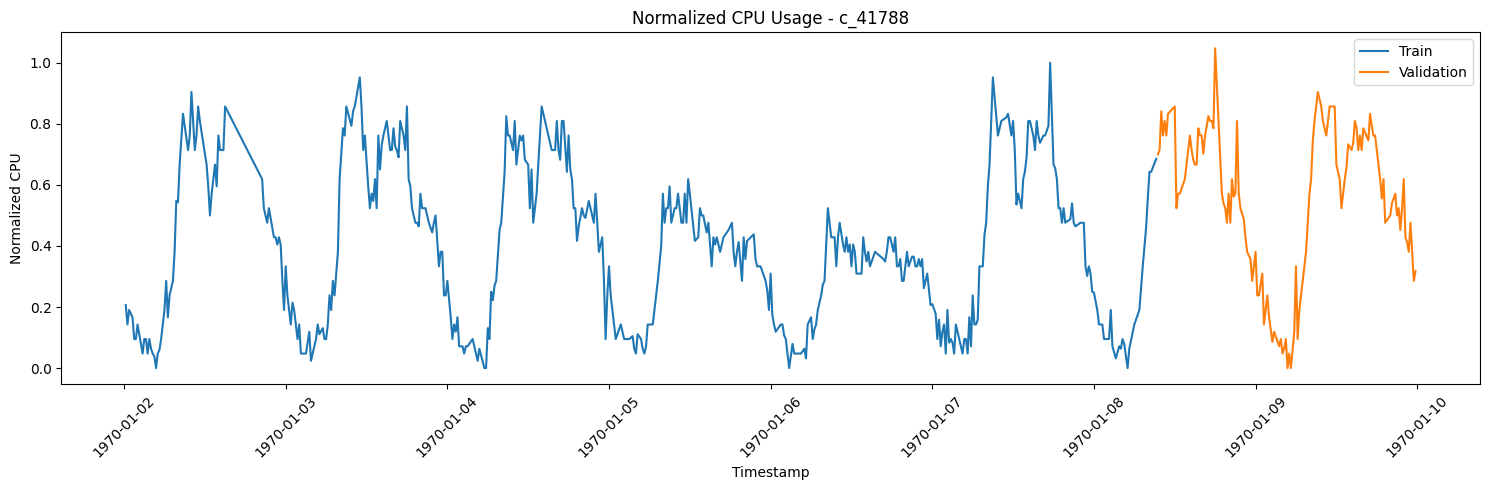

In [96]:
plt.figure(figsize=(15, 5))

# Train
plt.plot(train_c["time_stamp"], train_c["cpu_scaled"], label="Train")

# Validation
plt.plot(val_c["time_stamp"], val_c["cpu_scaled"], label="Validation")

plt.xlabel("Timestamp")
plt.ylabel("Normalized CPU")
plt.title(f"Normalized CPU Usage - {cid}")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

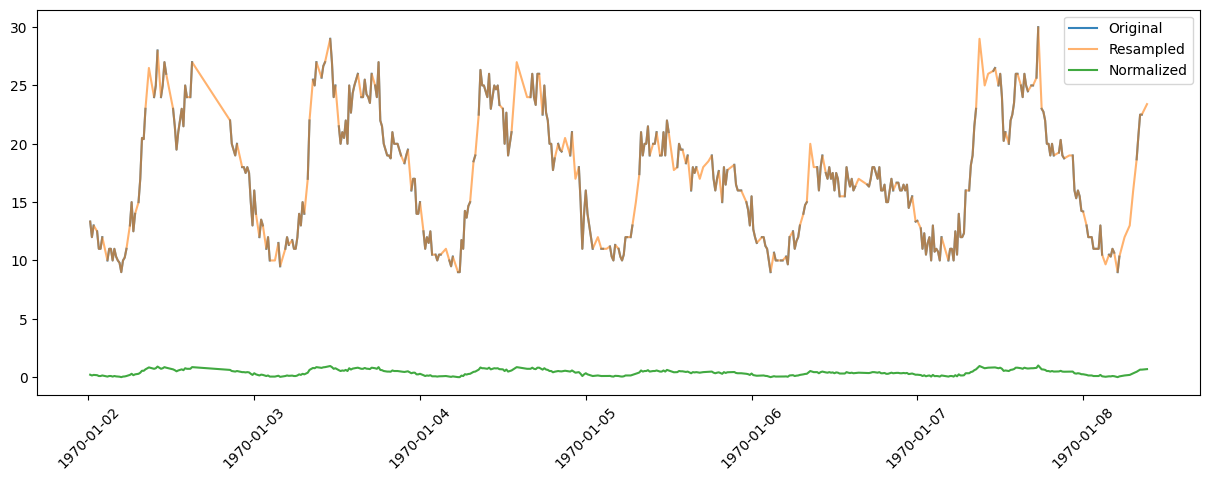

In [97]:
plt.figure(figsize=(15,5))

plt.plot(train_c["time_stamp"], train_c["cpu_util_percent"], label="Original", alpha=0.9)
plt.plot(train_c["time_stamp"], train_c["cpu_usage"], label="Resampled", alpha=0.6)
plt.plot(train_c["time_stamp"], train_c["cpu_scaled"], label="Normalized", alpha=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.show()

In [98]:
train_df.to_parquet(TRAIN_PARQUET_PATH)

In [99]:
val_df.to_parquet(VAL_PARQUET_PATH)

In [100]:
df_resampled.to_parquet(DF_RESAMPLED_PARQUET_PATH)

with open(SCALERS_PKL_PATH, "wb") as f:
    pickle.dump(scalers, f)

print(f"Saved scalers for {len(scalers)} containers to {SCALERS_PKL_PATH}")

# --- Container metadata export ---
retained_ids = set(train_df["container_id"].unique())
bad_container_ids = set(bad_containers["container_id"])
train_row_counts = train_df.groupby("container_id").size()
val_row_counts = val_df.groupby("container_id").size()

metadata = stats[["container_id", "type", "cv", "total_rows"]].rename(
    columns={
        "type": "pattern_type",
        "total_rows": "original_row_count",
    }
)
metadata["train_row_count"] = (
    metadata["container_id"].map(train_row_counts).fillna(0).astype(int)
)
metadata["val_row_count"] = (
    metadata["container_id"].map(val_row_counts).fillna(0).astype(int)
)
metadata["removed"] = ~metadata["container_id"].isin(retained_ids)

def _removal_reason(row):
    cid = row["container_id"]
    if cid in retained_ids:
        return None
    if cid in removed_degenerate:
        return "train_degenerate"
    if row["original_row_count"] < MIN_ROWS_HIGH_QUALITY:
        return "insufficient_rows"
    if cid in bad_container_ids:
        return "zero_mean_or_std_or_undefined_cv"
    return "excluded"

metadata["removal_reason"] = metadata.apply(_removal_reason, axis=1)
metadata.to_parquet(METADATA_PATH, index=False)
print(f"Saved container metadata to {METADATA_PATH}")

# --- Preprocessing summary ---
preprocessing_summary = {
    "containers_before_filtering": len(clean_selected),
    "containers_retained": len(retained_ids),
    "containers_removed": len(removed_degenerate),
    "removed_container_ids": removed_degenerate,
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "resampling_frequency": RESAMPLE_FREQ,
    "train_split_ratio": TRAIN_SPLIT_RATIO,
    "normalization_method": NORMALIZATION_METHOD,
}

with open(SUMMARY_JSON_PATH, "w") as f:
    json.dump(preprocessing_summary, f, indent=2)

print(f"Saved preprocessing summary to {SUMMARY_JSON_PATH}")
print(json.dumps(preprocessing_summary, indent=2))

Saved scalers for 484 containers to ../data/scalers.pkl
Saved container metadata to ../data/container_metadata.parquet
Saved preprocessing summary to ../data/preprocessing_summary.json
{
  "containers_before_filtering": 486,
  "containers_retained": 484,
  "containers_removed": 2,
  "removed_container_ids": [
    "c_14674",
    "c_39761"
  ],
  "train_samples": 296576,
  "val_samples": 74428,
  "resampling_frequency": "15min",
  "train_split_ratio": 0.8,
  "normalization_method": "MinMaxScaler(feature_range=(0, 1))"
}
